# §4.1 Exploratory Analysis of Inter-Institutional Heterogeneity

**Maps to:** Paper Section 4.1  
**Description:** Characterises the ELM19 dataset across 30 institutions.  
Produces all figures and tables for paper §4.1.

## Outputs

| Output file | Contents |
|---|---|
| `results/figures/01_exploratory_analysis/age_distribution_by_hospital.png` | Age boxplot per institution |
| `results/figures/01_exploratory_analysis/sex_distribution_by_hospital.png` | Sex stacked-bar per institution |
| `results/figures/01_exploratory_analysis/recording_duration_by_hospital.png` | Duration violin per institution |
| `results/figures/01_exploratory_analysis/classification_distribution_by_hospital.png` | Norm/patho counts per institution |
| `results/tables/01_exploratory_analysis/dataset_summary.csv` | Top-level dataset numbers |
| `results/tables/01_exploratory_analysis/age_stats_by_hospital.csv` | Age statistics per institution |
| `results/tables/01_exploratory_analysis/acquisition_metadata.csv` | Hardware/software per institution |
| `results/tables/01_exploratory_analysis/sampling_frequency_stats.csv` | Sampling frequency per institution |
| `results/tables/01_exploratory_analysis/acquisition_filter_stats.csv` | Acquisition filter settings |
| `results/tables/01_exploratory_analysis/section_4_1_summary.txt` | Copy-pasteable numbers for paper |


## Setup

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if Path.cwd().name != 'eeg-site-effects':
    os.chdir('../..')
print('Working directory:', Path.cwd())

DATA_DIR = Path('data/ELM19')
FIG_DIR  = Path('results/figures/newlabels/01_exploratory_analysis')
TAB_DIR  = Path('results/tables/newlabels/01_exploratory_analysis')
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

from src.visualization.style import apply_style, FIGSIZE_WIDE
apply_style()
DPI = 300

# Hospital anonymization mapping
_anon = pd.read_csv(DATA_DIR / 'hospital_anonymization_mapping.csv').dropna()
ANON_MAP = dict(zip(_anon['Original_Hospital'], _anon['Anonymized_ID']))
# Sorted order: H1, H2, ..., H30 (sort numerically by the integer part)
ANON_ORDER = sorted(ANON_MAP.values(), key=lambda h: int(h[1:]))

Working directory: /dmj/fizmed/kchorzela/licencjat/eeg-site-effects


## Section 1: Dataset Overview

Load the full ELM19 info file. Apply the ≥50 normal-recordings-per-institution threshold
to obtain ELM_s (30 institutions). Also load the pre-filtered normal subset ELM_n.

In [2]:
# Load main info file
elm19 = pd.read_csv(DATA_DIR / 'ELM19_enriched_info.csv')
print(f'Total recordings in ELM19: {len(elm19):,}')
print(f'Columns: {elm19.columns.tolist()}')
print(elm19.head(2))

Total recordings in ELM19: 55,787
Columns: ['examination_id', 'patient_original_id', 'age_dec', 'patient_sex', 'institution_id', 'classification', 'original_sfreq', 'n_channels_original', 'highpass_filter_acq', 'lowpass_filter_acq', 'n_samples', 'duration_sec', 'recording_date']
                                      examination_id  \
0  20220411-162228-{4fe29d03-5025-46ca-8e14-c3b3f...   
1  20220510-150544-{cc1f09f8-3b30-40b4-91f8-4cd70...   

                      patient_original_id    age_dec patient_sex  \
0  {d2bff7c3-8b81-4dfd-b4fe-4d9fe4c98a9e}  56.583333        Male   
1  {87ddf489-02db-4963-a966-b08709bbf636}  38.000000        Male   

  institution_id classification  original_sfreq  n_channels_original  \
0          TER_L           norm        250.0000                   19   
1            KLU          patho        249.9963                   21   

   highpass_filter_acq  lowpass_filter_acq  n_samples  duration_sec  \
0                 0.00               125.0     300000   12

In [3]:
# Apply ≥50 normal threshold to derive ELM_s
norm_counts = elm19[elm19['classification'] == 'norm'].groupby('institution_id').size()
included_institutions = norm_counts[norm_counts >= 50].index.tolist()

elm_s = elm19[elm19['institution_id'].isin(included_institutions)].copy()

# Apply anonymization
elm_s['institution_id'] = elm_s['institution_id'].map(ANON_MAP)

elm_n = elm_s[elm_s['classification'] == 'norm'].copy()

n_institutions = len(included_institutions)
n_total        = len(elm_s)
n_norm         = (elm_s['classification'] == 'norm').sum()
n_patho        = (elm_s['classification'] == 'patho').sum()

print(f'ELM_s: {n_total:,} recordings from {n_institutions} institutions')
print(f'  Normal  (ELM_n): {n_norm:,}')
print(f'  Patho  : {n_patho:,}')
print(f'  Excluded institutions (< 50 normal): {len(elm19["institution_id"].unique()) - n_institutions}')

ELM_s: 54,779 recordings from 30 institutions
  Normal  (ELM_n): 26,568
  Patho  : 28,211
  Excluded institutions (< 50 normal): 9


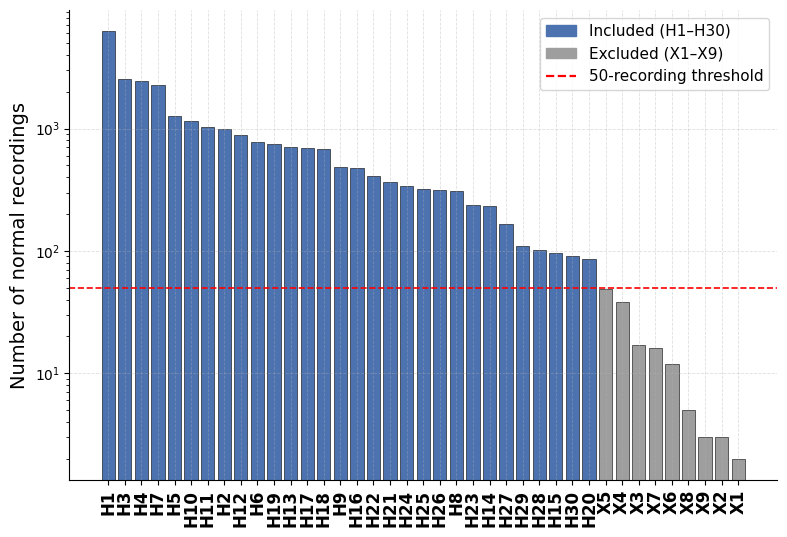

Saved ELM19_excluded_institutions_normal_recordings.png (included=30, excluded=9)


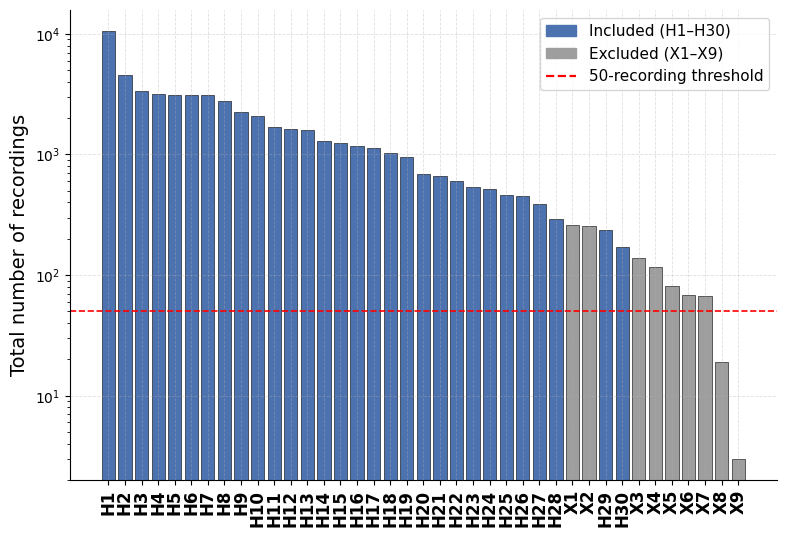

Saved ELM19_excluded_institutions_all_recordings.png (included=30, excluded=9)

Excluded-site mapping (X_i → original code):
  X1 = LOD (2 normals)
  X2 = LIP (3 normals)
  X3 = B123 (17 normals)
  X4 = BIL (38 normals)
  X5 = AND (49 normals)
  X6 = B21 (12 normals)
  X7 = unknown (16 normals)
  X8 = SL1 (5 normals)
  X9 = DZI (3 normals)


In [18]:
# Institution histograms (39 institutions): normal-recording count and total-recording count
# Bars sorted descending; 30 included sites labelled H1..H30 per ANON_MAP, 9 excluded sites
# labelled X1..X9 (sorted by descending normal count for a stable mapping across both subfigures).

# Counts on the full ELM19 (39 institutions, before filtering)
norm_counts_full = elm19[elm19['classification'] == 'norm'].groupby('institution_id').size()
all_counts_full  = elm19.groupby('institution_id').size()

THRESHOLD = 50

# Build a stable map for the 9 excluded sites: X1 = excluded with most normals, X9 = fewest
included_origs = set(ANON_MAP.keys())
excluded_origs = sorted(set(elm19['institution_id'].unique()) - included_origs)
excl_all_sorted = all_counts_full.reindex(excluded_origs).fillna(0).sort_values(ascending=False)
EXCL_MAP = {orig: f'X{i+1}' for i, orig in enumerate(excl_all_sorted.index)}
COMBINED_MAP = {**ANON_MAP, **EXCL_MAP}


def _plot_inst_hist(counts, threshold, title, fname, ylabel='Number of recordings'):
    s = counts.sort_values(ascending=False)
    labels = [COMBINED_MAP.get(orig, '?') for orig in s.index]
    colors = ['#4C72B0' if l.startswith('H') else '#9E9E9E' for l in labels]

    fig, ax = plt.subplots(figsize=(8, 5.5))
    ax.bar(range(len(s)), s.values, color=colors, edgecolor='black', linewidth=0.4)
    ax.axhline(threshold, color='red', linestyle='--', linewidth=1.2,
               label=f'{threshold}-recording inclusion threshold')

    ax.set_xticks(range(len(s)))
    ax.set_xticklabels(labels, rotation=90, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_yscale('log')

    # Legend with colour key
    from matplotlib.patches import Patch
    leg_handles = [
        Patch(color='#4C72B0', label='Included (H1–H30)'),
        Patch(color='#9E9E9E', label='Excluded (X1–X9)'),
        plt.Line2D([0], [0], color='red', linestyle='--',
                   label=f'{threshold}-recording threshold'),
    ]
    ax.legend(handles=leg_handles, loc='upper right', fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig(FIG_DIR / fname, dpi=DPI, bbox_inches='tight')
    plt.show()
    n_included = sum(1 for l in labels if l.startswith('H'))
    n_excluded = sum(1 for l in labels if l.startswith('X'))
    print(f'Saved {fname} (included={n_included}, excluded={n_excluded})')


_plot_inst_hist(norm_counts_full, THRESHOLD,
                'Normal recordings per institution (39 sites in ELM19)',
                'ELM19_excluded_institutions_normal_recordings.png',
                ylabel='Number of normal recordings')

_plot_inst_hist(all_counts_full, THRESHOLD,
                'All recordings per institution (39 sites in ELM19)',
                'ELM19_excluded_institutions_all_recordings.png',
                ylabel='Total number of recordings')

print('\nExcluded-site mapping (X_i → original code):')
for x, orig in zip(EXCL_MAP.values(), EXCL_MAP.keys()):
    print(f'  {x} = {orig} ({int(norm_counts_full.get(orig, 0))} normals)')


In [5]:
# Load pre-filtered normal subset (sanity check)
elm_n_filtered = pd.read_csv(DATA_DIR / 'filtered' / 'ELM19_enriched_info_filtered_norm.csv')
print(f'Pre-filtered ELM_n: {len(elm_n_filtered):,} recordings, '
      f'{elm_n_filtered["institution_id"].nunique()} institutions')

Pre-filtered ELM_n: 26,568 recordings, 30 institutions


In [6]:
# Save dataset summary
summary = pd.DataFrame([{
    'n_institutions_total': elm19['institution_id'].nunique(),
    'n_institutions_elm_s': n_institutions,
    'n_institutions_excluded': elm19['institution_id'].nunique() - n_institutions,
    'n_recordings_elm_s': n_total,
    'n_norm': int(n_norm),
    'n_patho': int(n_patho),
    'norm_fraction': round(n_norm / n_total, 4),
}])
summary.to_csv(TAB_DIR / 'dataset_summary.csv', index=False)
print('Saved dataset_summary.csv')
summary

Saved dataset_summary.csv


,n_institutions_total,n_institutions_elm_s,n_institutions_excluded,n_recordings_elm_s,n_norm,n_patho,norm_fraction
0,39,30,9,54779,26568,28211,0.485


## Section 2: Demographics

Age and sex distributions across the 30 included institutions.

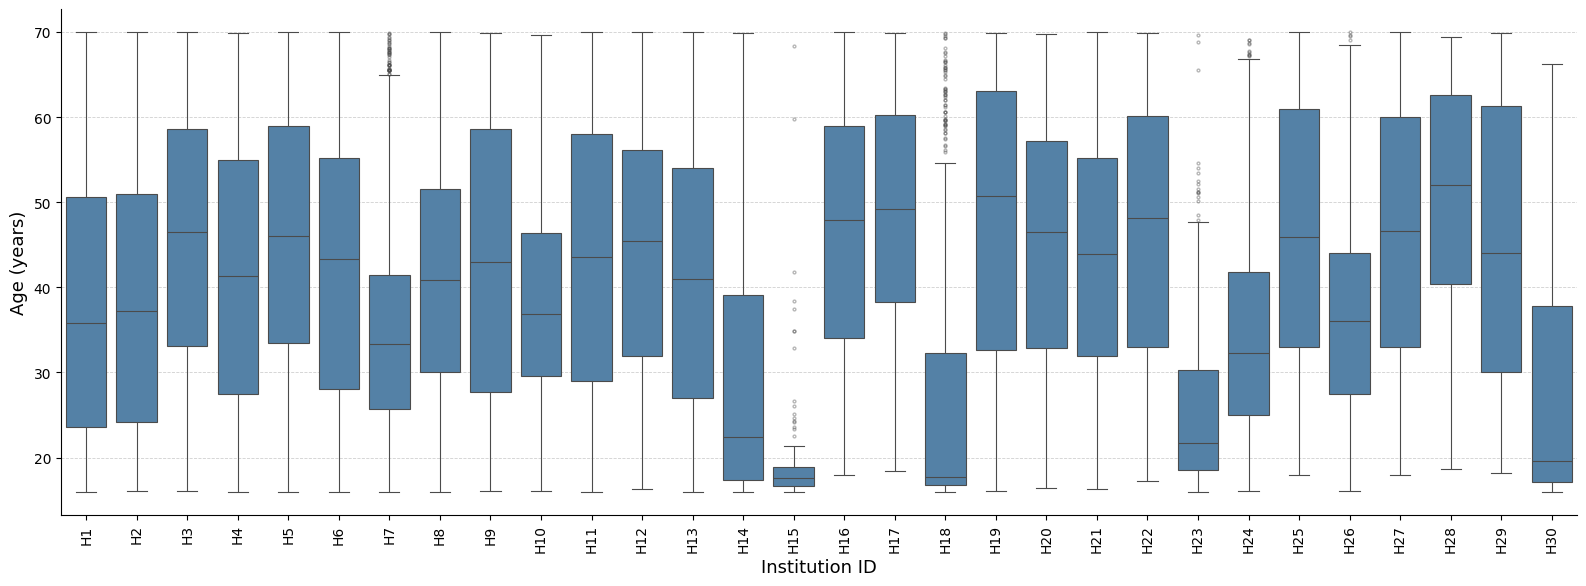

Saved age_distribution_by_hospital.png


In [7]:
# Age distribution – boxplot, sorted H1…H30 (ELM_n: normal recordings only)
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
sns.boxplot(
    data=elm_n,
    x='institution_id', y='age_dec',
    order=ANON_ORDER,
    color='steelblue',
    linewidth=0.8,
    flierprops=dict(marker='o', markersize=2, alpha=0.4),
    ax=ax,
)
ax.set_xlabel('Institution ID', fontsize=13)
ax.set_ylabel('Age (years)', fontsize=13)
ax.tick_params(axis='x', rotation=90, labelsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(FIG_DIR / 'age_distribution_by_hospital.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved age_distribution_by_hospital.png')

In [8]:
# Age statistics table (ELM_n: normal recordings only)
age_stats = (
    elm_n.groupby('institution_id')['age_dec']
    .agg(mean='mean', median='median', std='std', min='min', max='max', count='count')
    .round(2)
    .reset_index()
)
age_stats.to_csv(TAB_DIR / 'age_stats_by_hospital.csv', index=False)
print('Saved age_stats_by_hospital.csv')
age_stats.sort_values('institution_id')

Saved age_stats_by_hospital.csv


,institution_id,mean,median,std,min,max,count
0,H1,37.71,35.79,15.42,16.00,70.00,6222
1,H10,39.04,36.92,12.60,16.08,69.67,1148
2,H11,43.52,43.58,16.04,16.00,70.00,1033
3,H12,44.19,45.42,14.54,16.25,70.00,889
4,H13,41.03,41.00,15.95,16.00,70.00,704
5,H14,29.37,22.42,14.69,16.00,69.92,232
6,H15,20.26,17.62,8.25,16.00,68.33,96
7,H16,46.30,47.92,14.68,18.00,70.00,473
8,H17,48.12,49.17,13.72,18.42,69.92,691
9,H18,26.29,17.75,14.98,16.00,69.83,677


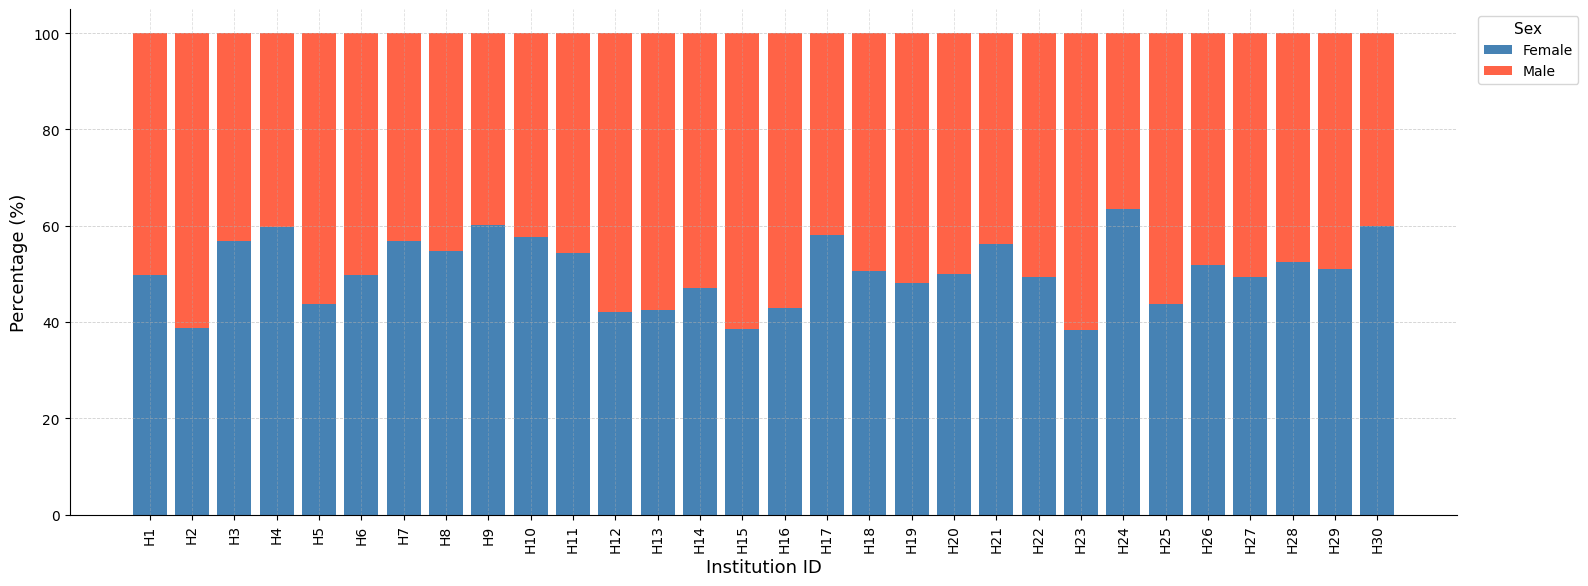

Saved sex_distribution_by_hospital.png


In [9]:
# Sex distribution – stacked bar (% female / male), sorted H1…H30 (ELM_n)
sex_counts = (
    elm_n.groupby(['institution_id', 'patient_sex'])
    .size()
    .reset_index(name='count')
)
sex_pivot = sex_counts.pivot(index='institution_id', columns='patient_sex', values='count').fillna(0)
sex_pct = sex_pivot.div(sex_pivot.sum(axis=1), axis=0) * 100
sex_pct = sex_pct.loc[ANON_ORDER]

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
bottom = np.zeros(len(sex_pct))
colors = {'Female': 'steelblue', 'Male': 'tomato'}
for sex in ['Female', 'Male']:
    if sex in sex_pct.columns:
        ax.bar(sex_pct.index, sex_pct[sex], bottom=bottom, label=sex, color=colors[sex])
        bottom += sex_pct[sex].values

ax.set_xlabel('Institution ID', fontsize=13)
ax.set_ylabel('Percentage (%)', fontsize=13)
ax.tick_params(axis='x', rotation=90, labelsize=10)
ax.set_ylim(0, 105)
ax.legend(title='Sex', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(FIG_DIR / 'sex_distribution_by_hospital.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved sex_distribution_by_hospital.png')

## Section 3: Recording Protocols

Duration distribution and norm/patho split per institution.

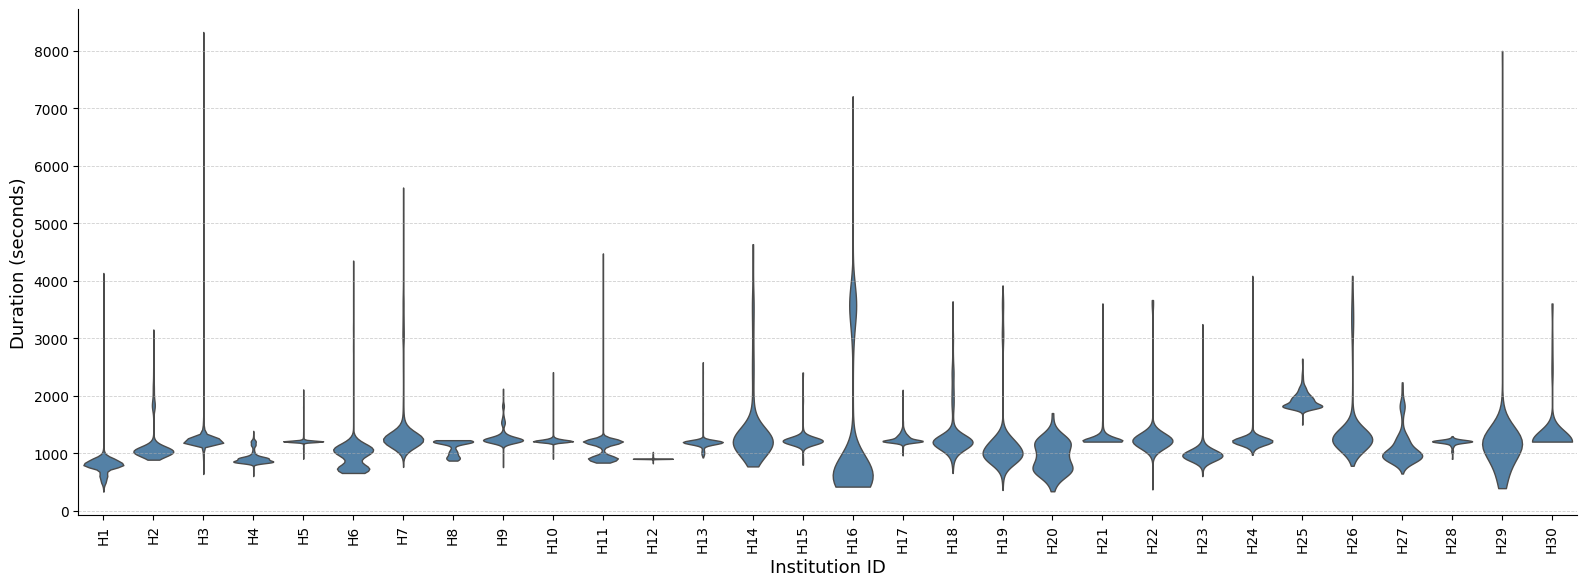

Saved recording_duration_by_hospital.png


In [10]:
# Recording duration – violin plot, sorted H1…H30 (ELM_n)
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
sns.violinplot(
    data=elm_n,
    x='institution_id', y='duration_sec',
    order=ANON_ORDER,
    color='steelblue',
    inner=None,
    cut=0,
    linewidth=1.0,
    density_norm='width',
    width=0.8,
    ax=ax,
)
ax.set_xlabel('Institution ID', fontsize=13)
ax.set_ylabel('Duration (seconds)', fontsize=13)
ax.tick_params(axis='x', rotation=90, labelsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(FIG_DIR / 'recording_duration_by_hospital.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved recording_duration_by_hospital.png')

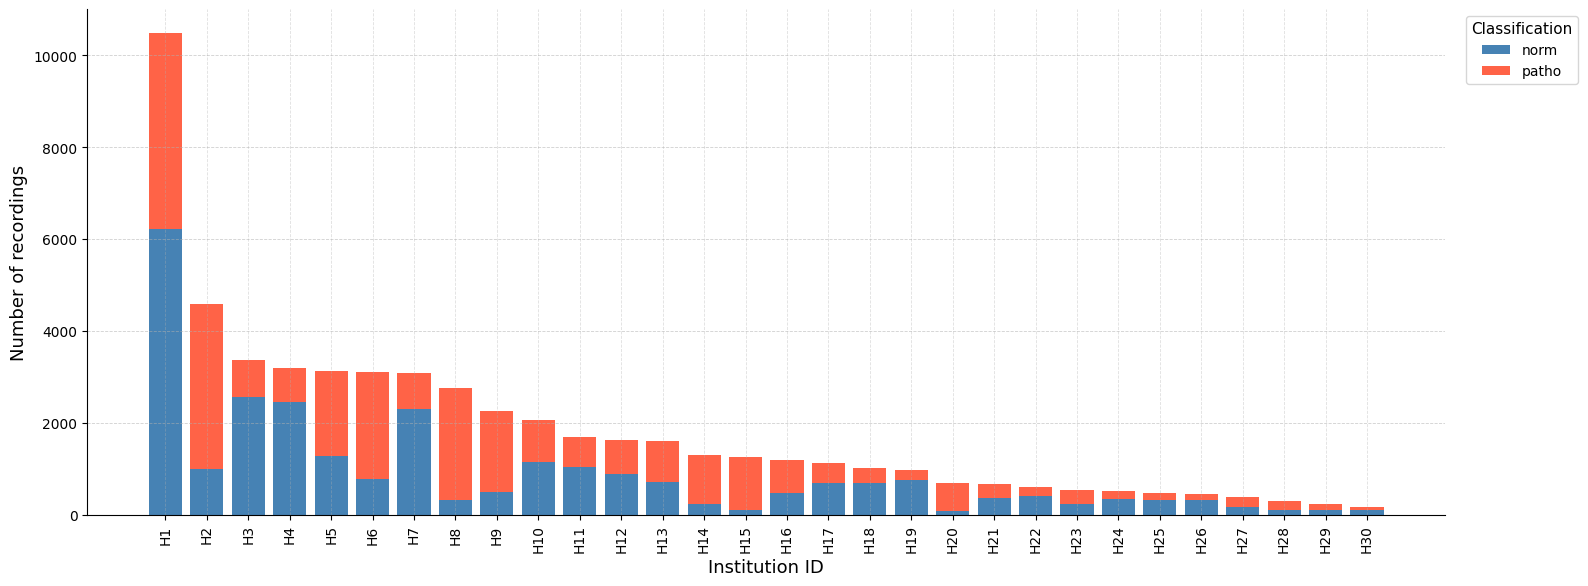

Saved classification_distribution_by_hospital.png


In [11]:
# Classification distribution – stacked bar (norm / patho counts), sorted H1…H30
clf_counts = (
    elm_s.groupby(['institution_id', 'classification'])
    .size()
    .reset_index(name='count')
)
clf_pivot = clf_counts.pivot(index='institution_id', columns='classification', values='count').fillna(0)
clf_pivot = clf_pivot.loc[ANON_ORDER]

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
bottom = np.zeros(len(clf_pivot))
clf_colors = {'norm': 'steelblue', 'patho': 'tomato'}
for cls in ['norm', 'patho']:
    if cls in clf_pivot.columns:
        ax.bar(clf_pivot.index, clf_pivot[cls], bottom=bottom, label=cls, color=clf_colors[cls])
        bottom += clf_pivot[cls].values

ax.set_xlabel('Institution ID', fontsize=13)
ax.set_ylabel('Number of recordings', fontsize=13)
ax.tick_params(axis='x', rotation=90, labelsize=10)
ax.legend(title='Classification', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(FIG_DIR / 'classification_distribution_by_hospital.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved classification_distribution_by_hospital.png')

## Section 4: Acquisition Metadata

Hardware model, software version, specialization, and acquisition filter settings
per institution. Uses `data/ELM19/hospital_metadata.csv`.

In [12]:
def parse_software_versions(s):
    """Parse a bracketed comma-separated version string into a list."""
    s = str(s).strip()
    if not s or s in ('nan', '--', 'NaN'):
        return []
    s = s.strip('[]')
    return [x.strip() for x in s.split(',') if x.strip()]


def parse_specialization(text):
    """Parse a multiline specialization field into a list of specializations."""
    if pd.isna(text) or str(text).strip() == '':
        return []
    items = [line.strip() for line in str(text).split('\n') if line.strip()]
    items = [item.lstrip('- ').strip() for item in items if item.lstrip('- ').strip()]
    return items

In [13]:
# Load cleaned hospital metadata
hw = pd.read_csv(DATA_DIR / 'hospital_metadata.csv', dtype={'hardware': str, 'software': str})

# Keep only included institutions then anonymize
hw = hw[hw['institution_id'].isin(included_institutions)].copy()
hw['institution_id'] = hw['institution_id'].map(ANON_MAP)

# Drop duplicate anonymized IDs (two institutions shared the original 'MOR' code → both become H19;
# they have identical hardware/software so we keep the first)
hw = hw.drop_duplicates(subset='institution_id', keep='first')

# Some included institutions have no metadata row (LUMICE→H1, ZOZLO→H3, KATMOJPRZ→H16)
# Add them as NaN rows so all 30 institutions appear in the output table
missing_ids = sorted(set(ANON_ORDER) - set(hw['institution_id']), key=lambda h: int(h[1:]))
if missing_ids:
    hw = pd.concat([hw, pd.DataFrame({'institution_id': missing_ids})], ignore_index=True)

# Manual software fixes for hospitals with known messy entries
hw.loc[hw['institution_id'] == ANON_MAP['SZC'],  'software'] = '6'
hw.loc[hw['institution_id'] == ANON_MAP['SRK'],  'software'] = '12'
hw.loc[hw['institution_id'] == ANON_MAP['KLU'],  'software'] = '[6.90.3.1, 10.3.8.1, 14.0.2.5]'
hw.loc[hw['institution_id'] == ANON_MAP['OST'],  'software'] = '[12.2.1.2, 14.1.1.1]'
hw.loc[hw['institution_id'] == ANON_MAP['KIEG'], 'software'] = '[10.3.8.1, 15.0.4.0]'

# Parse specialization
hw['specialization_list'] = hw['specialization'].apply(parse_specialization)

# Mark unknown hardware/software as NaN
hw['hardware'] = hw['hardware'].replace('--', np.nan)
hw['software'] = hw['software'].replace('--', np.nan)

# Aggregate per-hospital sampling frequency and acquisition filters from EDF headers
def _clean_sfreq(vals):
    return sorted(set(int(round(v)) for v in vals if pd.notna(v)))

def _clean_hp(vals):
    out = set()
    for v in vals:
        if pd.isna(v): continue
        out.add(0 if abs(v) < 0.01 else 0.16 if 0.1 <= v <= 0.2 else round(v, 2))
    return sorted(out)

def _clean_lp(vals):
    remap = {126: 125}
    out = set()
    for v in vals:
        if pd.isna(v): continue
        r = int(round(v))
        out.add(remap.get(r, r))
    return sorted(out)

sfreq_per_h = elm_n.groupby('institution_id')['original_sfreq'].apply(_clean_sfreq)
hp_per_h = elm_n.groupby('institution_id')['highpass_filter_acq'].apply(_clean_hp)
lp_per_h = elm_n.groupby('institution_id')['lowpass_filter_acq'].apply(_clean_lp)

hw = hw.merge(sfreq_per_h.rename('sfreq_list'), left_on='institution_id', right_index=True, how='left')
hw = hw.merge(hp_per_h.rename('hp_list'), left_on='institution_id', right_index=True, how='left')
hw = hw.merge(lp_per_h.rename('lp_list'), left_on='institution_id', right_index=True, how='left')

# String columns for CSV/display
hw['sfreq_hz'] = hw['sfreq_list'].apply(lambda x: ', '.join(str(v) for v in x) if isinstance(x, list) else '---')
hw['highpass_hz'] = hw['hp_list'].apply(lambda x: ', '.join(str(v) for v in x) if isinstance(x, list) else '---')
hw['lowpass_hz'] = hw['lp_list'].apply(lambda x: ', '.join(str(v) for v in x) if isinstance(x, list) else '---')

print(f'Total institutions in metadata table: {len(hw)}')
print(f'Hardware coverage: {hw["hardware"].notna().sum()} / {len(hw)} institutions')
print(f'Software coverage: {hw["software"].notna().sum()} / {len(hw)} institutions')
print(f'No metadata (NaN rows): {missing_ids}')
print()
print(hw[['institution_id', 'hardware', 'sfreq_hz', 'highpass_hz', 'lowpass_hz']].sort_values(
    'institution_id', key=lambda s: s.map(lambda h: int(h[1:]))).to_string(index=False))


Total institutions in metadata table: 30
Hardware coverage: 21 / 30 institutions
Software coverage: 20 / 30 institutions
No metadata (NaN rows): ['H3', 'H16', 'H25']

institution_id hardware      sfreq_hz highpass_hz   lowpass_hz
            H1     1032      250, 251     0, 0.16      47, 125
            H2     1032           250           0          125
            H3      NaN           250        0.16           97
            H4      NaN           250           0          125
            H5     1032           250           0          125
            H6     1032      250, 300           0     125, 150
            H7     1032           250           0          125
            H8     1032      250, 600           0     125, 300
            H9     1032           250           0          125
           H10      NaN           250           0          125
           H11     1032           250     0, 0.16      97, 125
           H12     1032           250           0          125
           H13

In [14]:
# Save acquisition metadata table
acq_meta = hw[['institution_id', 'hardware', 'software',
               'sfreq_hz', 'highpass_hz', 'lowpass_hz']].copy()
acq_meta.to_csv(TAB_DIR / 'acquisition_metadata.csv', index=False)
print('Saved acquisition_metadata.csv')
acq_meta


Saved acquisition_metadata.csv


,institution_id,hardware,software,sfreq_hz,highpass_hz,lowpass_hz
0,H1,1032,6,"250, 251","0, 0.16","47, 125"
1,H20,1032,6.90.0.8,250,0,125
2,H30,NaN,NaN,250,"0, 0.16","97, 125"
3,H27,1032,6.82,250,"0, 0.16","71, 125"
4,H26,NaN,NaN,250,0,125
5,H28,1032,6.90.3.1,250,0,125
6,H24,1042,12,256,0.16,"104, 1500"
7,H2,1032,nie mam informacji,250,0,125
8,H18,NaN,NaN,"250, 256","0, 0.16","47, 104, 125"
9,H7,1032,6.90.2.0,250,0,125


In [15]:
# Sampling frequency statistics (ELM_n: normal recordings only)
sfreq_stats = (
    elm_n.groupby('institution_id')['original_sfreq']
    .agg(
        mode=lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
        unique_values=lambda x: sorted(x.dropna().unique().tolist()),
        n_unique=lambda x: x.nunique(),
    )
    .reset_index()
)
sfreq_stats.to_csv(TAB_DIR / 'sampling_frequency_stats.csv', index=False)
print('Saved sampling_frequency_stats.csv')
print(sfreq_stats.to_string(index=False))

Saved sampling_frequency_stats.csv
institution_id       mode                                                             unique_values  n_unique
            H1 250.000000                                         [249.9875006249688, 250.0, 251.0]         3
           H10 250.000000                                                                   [250.0]         1
           H11 249.987501                                                       [249.9875006249688]         1
           H12 250.000000                                                                   [250.0]         1
           H13 250.000000                             [249.9955834113597, 249.9963000547592, 250.0]         3
           H14 250.000000  [249.9786518231343, 249.9875006249688, 250.0, 251.0, 255.99620272299293]         5
           H15 249.987501                                                [249.9875006249688, 250.0]         2
           H16 250.000000                                                            

In [16]:
# Acquisition filter statistics (ELM_n: normal recordings only)
filter_stats = (
    elm_n.groupby('institution_id')[['highpass_filter_acq', 'lowpass_filter_acq']]
    .agg(
        highpass_unique=('highpass_filter_acq', lambda x: sorted(x.dropna().unique().tolist())),
        lowpass_unique=('lowpass_filter_acq', lambda x: sorted(x.dropna().unique().tolist())),
        highpass_mode=('highpass_filter_acq', lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
        lowpass_mode=('lowpass_filter_acq', lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
    )
    .reset_index()
)
filter_stats.to_csv(TAB_DIR / 'acquisition_filter_stats.csv', index=False)
print('Saved acquisition_filter_stats.csv')
filter_stats

Saved acquisition_filter_stats.csv


,institution_id,highpass_unique,lowpass_unique,highpass_mode,lowpass_mode
0,H1,"[0.0, 0.16]","[47.0, 124.99375031248437, 125.0, 125.5]",0.00,125.00000
1,H10,[0.0],[125.0],0.00,125.00000
2,H11,"[0.0, 0.16]","[97.0, 124.99375031248437]",0.00,124.99375
3,H12,[0.0],[125.0],0.00,125.00000
4,H13,"[0.0, 0.16]","[47.0, 97.0, 125.0]",0.16,125.00000
5,H14,"[0.0, 0.16]","[97.0, 104.0, 125.0, 125.5]",0.00,125.00000
6,H15,"[0.0, 0.16]","[97.0, 124.99375031248437, 125.0]",0.16,97.00000
7,H16,[0.0],[125.0],0.00,125.00000
8,H17,"[0.0, 0.16, 0.18]","[104.0, 125.0]",0.16,104.00000
9,H18,"[0.0, 0.16]","[47.0, 104.0, 125.0]",0.16,125.00000


## Section 5: Summary Statistics for Paper

Collect all key numbers needed for the §4.1 text placeholders.

In [17]:
# Hardware distribution
hw_counts = hw['hardware'].value_counts()
hw_1032 = int(hw_counts.get('1032', 0))
hw_1042 = int(hw_counts.get('1042', 0))
hw_exg  = int(hw_counts.get('ExG', 0))
hw_unknown = int(hw['hardware'].isna().sum())

# Software
hw_with_sw = hw[hw['software'].notna() & ~hw['software'].isin(['--', 'nan'])]
n_with_sw = len(hw_with_sw)

# Sampling frequency (ELM_n)
dominant_sfreq = elm_n['original_sfreq'].mode().iloc[0]
n_600hz = (elm_n['original_sfreq'] >= 600).sum()

# Acquisition filters (ELM_n)
n_highpass_zero = (elm_n['highpass_filter_acq'] == 0).sum()
n_highpass_016  = (elm_n['highpass_filter_acq'].round(2) == 0.16).sum()

summary_lines = [
    f"=== §4.1 Key Numbers ===",
    f"",
    f"DATASET OVERVIEW",
    f"  Total institutions in ELM19 (raw): {elm19['institution_id'].nunique()}",
    f"  Institutions in ELM_s (≥50 norm): {n_institutions}",
    f"  Excluded (< 50 normal): {elm19['institution_id'].nunique() - n_institutions}",
    f"  Total recordings in ELM_s: {n_total:,}",
    f"  Normal recordings: {n_norm:,}",
    f"  Pathological recordings: {n_patho:,}",
    f"  Norm fraction: {n_norm/n_total:.1%}",
    f"",
    f"DEMOGRAPHICS (ELM_n)",
    f"  Age range: {elm_n['age_dec'].min():.1f} – {elm_n['age_dec'].max():.1f} years",
    f"  Median age overall: {elm_n['age_dec'].median():.1f} years",
    f"  Sex: {(elm_n['patient_sex']=='Female').sum():,} female, {(elm_n['patient_sex']=='Male').sum():,} male",
    f"",
    f"RECORDING DURATION (ELM_n)",
    f"  Median duration: {elm_n['duration_sec'].median():.0f} s",
    f"  Range: {elm_n['duration_sec'].min():.0f} – {elm_n['duration_sec'].max():.0f} s",
    f"",
    f"ACQUISITION HARDWARE",
    f"  Hardware 1032: {hw_1032} institutions",
    f"  Hardware 1042: {hw_1042} institutions",
    f"  Hardware ExG : {hw_exg} institutions",
    f"  Unknown hw   : {hw_unknown} institutions",
    f"",
    f"ACQUISITION SOFTWARE",
    f"  Institutions with known software: {n_with_sw} / {n_institutions}",
    f"",
    f"SAMPLING FREQUENCY (ELM_n)",
    f"  Dominant sfreq: {dominant_sfreq} Hz",
    f"  Recordings ≥600 Hz: {n_600hz:,}",
    f"",
    f"ACQUISITION FILTERS (ELM_n)",
    f"  Recordings with highpass=0 Hz : {n_highpass_zero:,}",
    f"  Recordings with highpass=0.16 Hz: {n_highpass_016:,}",
]

summary_text = "\n".join(summary_lines)
print(summary_text)

with open(TAB_DIR / 'section_4_1_summary.txt', 'w') as f:
    f.write(summary_text)
print("\nSaved section_4_1_summary.txt")

=== §4.1 Key Numbers ===

DATASET OVERVIEW
  Total institutions in ELM19 (raw): 39
  Institutions in ELM_s (≥50 norm): 30
  Excluded (< 50 normal): 9
  Total recordings in ELM_s: 54,779
  Normal recordings: 26,568
  Pathological recordings: 28,211
  Norm fraction: 48.5%

DEMOGRAPHICS (ELM_n)
  Age range: 16.0 – 70.0 years
  Median age overall: 39.2 years
  Sex: 13,746 female, 12,822 male

RECORDING DURATION (ELM_n)
  Median duration: 1152 s
  Range: 336 – 8322 s

ACQUISITION HARDWARE
  Hardware 1032: 17 institutions
  Hardware 1042: 4 institutions
  Hardware ExG : 0 institutions
  Unknown hw   : 9 institutions

ACQUISITION SOFTWARE
  Institutions with known software: 20 / 30

SAMPLING FREQUENCY (ELM_n)
  Dominant sfreq: 250.0 Hz
  Recordings ≥600 Hz: 10

ACQUISITION FILTERS (ELM_n)
  Recordings with highpass=0 Hz : 20,843
  Recordings with highpass=0.16 Hz: 5,466

Saved section_4_1_summary.txt
